
--- DATA PREVIEW ---
   loan_id  gender married  income  loan_amount  credit_score  \
0        1    Male     Yes   50000     200000.0           750   
1        2  Female      No   30000     100000.0           680   
2        3    Male     Yes   60000     250000.0           720   
3        4  Female      No   25000     120000.0           650   
4        5    Male     Yes   80000     300000.0           800   

   employment_years loan_status  
0                 5    Approved  
1                 2    Rejected  
2                 6    Approved  
3                 1    Rejected  
4                10    Approved  

--- COLUMNS ---
Index(['loan_id', 'gender', 'married', 'income', 'loan_amount', 'credit_score',
       'employment_years', 'loan_status'],
      dtype='object')

Accuracy: 1.0


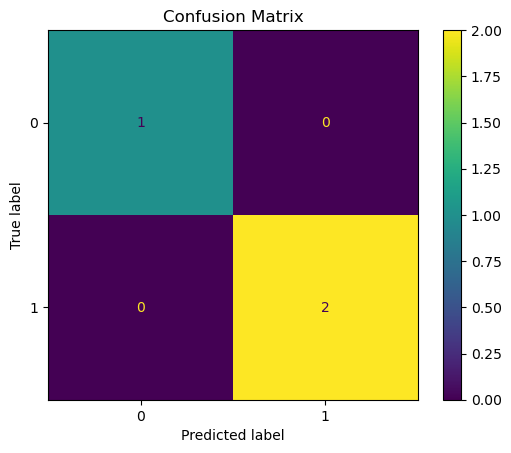

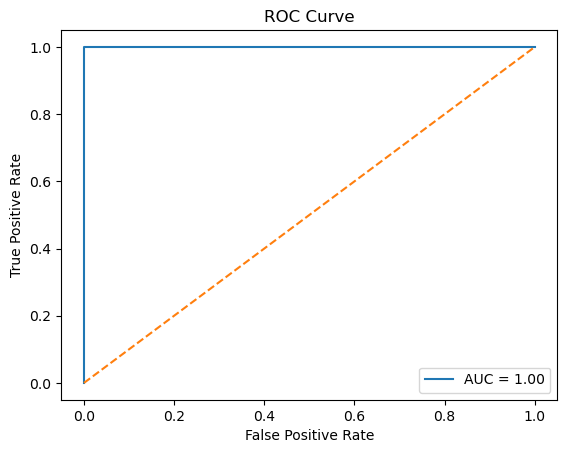

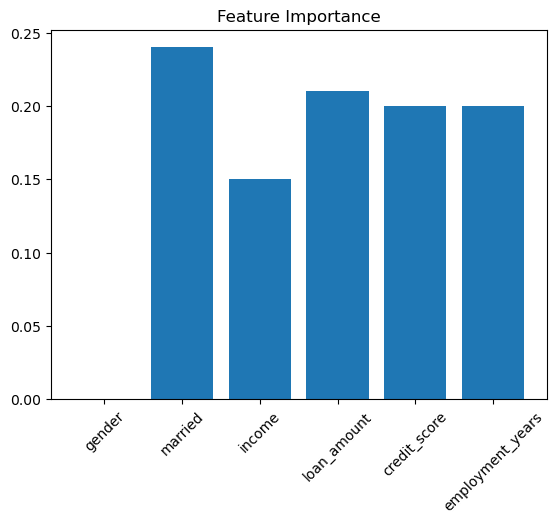


Loan Prediction Project Completed Successfully!


In [4]:
# LOAN PREDICTION ML PROJECT

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

df = pd.read_csv("data1.csv")

print("\n--- DATA PREVIEW ---")
print(df.head())

print("\n--- COLUMNS ---")
print(df.columns)

df['loan_amount'] = df['loan_amount'].fillna(df['loan_amount'].mean())

df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
df['married'] = df['married'].map({'No': 0, 'Yes': 1})
df['loan_status'] = df['loan_status'].map({'Rejected': 0, 'Approved': 1})

X = df[['gender', 'married', 'income', 'loan_amount', 'credit_score', 'employment_years']]
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

if len(set(y_test)) > 1:
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
else:
    print(" ROC cannot be plotted (only one class in test data)")

importance = model.feature_importances_

plt.figure()
plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

print("\nLoan Prediction Project Completed Successfully!")